<a href="https://colab.research.google.com/github/SydAt1/Eye_Disease_Classification/blob/main/notebooks/XGBoost_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, balanced_accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# LOAD DATA
df = pd.read_csv("prepped_NHIS_dataset.csv")

print("Dataset shape:", df.shape)
print("\nRisk Level Distribution:")
print(df["Risk_Level"].value_counts(normalize=True).round(3))


Dataset shape: (11295, 10)

Risk Level Distribution:
Risk_Level
0    0.500
1    0.253
2    0.168
3    0.079
Name: proportion, dtype: float64


In [6]:
df.drop(columns=["Unnamed: 0"], inplace=True)

feature_cols = [c for c in df.columns if c not in ["Data_Value", "Risk_Level"]]

## Feature/Target and Train/Test Split

In [7]:
X = df[feature_cols]
y = df["Risk_Level"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [8]:
# Calculate class weights for imbalanced data
class_counts = y_train.value_counts().sort_index()
total_samples = len(y_train)
n_classes = len(class_counts)
class_weights = {i: total_samples / (n_classes * class_counts[i]) for i in class_counts.index}

In [9]:
print("\nClass weights:", class_weights)


Class weights: {0: np.float64(0.5005064573309699), 1: np.float64(0.988744372186093), 2: np.float64(1.4860902255639097), 3: np.float64(3.147292993630573)}


## Training XGBoost Classifier


In [10]:
xgb_clf = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    gamma=0,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

In [11]:
# Fit with sample weights
sample_weights = np.array([class_weights[label] for label in y_train])
xgb_clf.fit(X_train, y_train, sample_weight=sample_weights)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:08:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1,
              num_parallel_tree=None, ...)

In [12]:
# PREDICTIONS
y_train_pred = xgb_clf.predict(X_train)
y_test_pred = xgb_clf.predict(X_test)

## Model Evaluation

In [13]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
balanced_acc = balanced_accuracy_score(y_test, y_test_pred)

print(f"\nTraining Accuracy:       {train_acc:.4f}")
print(f"Test Accuracy:           {test_acc:.4f}")
print(f"Balanced Test Accuracy:  {balanced_acc:.4f}\n")

print("Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred))


Training Accuracy:       0.8060
Test Accuracy:           0.6751
Balanced Test Accuracy:  0.6402

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.85      0.67      0.75      1693
           1       0.77      0.72      0.74       857
           2       0.67      0.75      0.71       570
           3       0.18      0.42      0.26       269

    accuracy                           0.68      3389
   macro avg       0.62      0.64      0.61      3389
weighted avg       0.75      0.68      0.70      3389



In [14]:
# Feature Importance
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": xgb_clf.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nTop 20 Most Important Features:")
print(importance_df.head(20).to_string(index=False))


Top 20 Most Important Features:
             Feature  Importance
            Question    0.330833
           YearStart    0.292959
           Age_range    0.140186
RiskFactorResponseID    0.069194
       RaceEthnicity    0.062443
                 Sex    0.057819
        RiskFactorID    0.046567


### Tuning XGBoost with Custom Weights

In [15]:
# Tuned XGBoost with custom weights
xgb_clf = XGBClassifier(
    n_estimators=600,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

# Adjust class weights manually (similar to RF approach)
custom_weights = {0: 1, 1: 1.2, 2: 1.5, 3: 3}
sample_weights = np.array([custom_weights[label] for label in y_train])

xgb_clf.fit(X_train, y_train, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.85, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=-1,
              num_parallel_tree=None, ...)

In [16]:
# PREDICTIONS
y_train_pred = xgb_clf.predict(X_train)
y_test_pred = xgb_clf.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
balanced_acc = balanced_accuracy_score(y_test, y_test_pred)

print(f"\nTuned Model Results")
print(f"Training Accuracy:       {train_acc:.4f}")
print(f"Test Accuracy:           {test_acc:.4f}")
print(f"Balanced Test Accuracy:  {balanced_acc:.4f}\n")

print("Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred))


Tuned Model Results
Training Accuracy:       0.8696
Test Accuracy:           0.7704
Balanced Test Accuracy:  0.6774

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.85      0.86      0.85      1693
           1       0.78      0.76      0.77       857
           2       0.75      0.72      0.73       570
           3       0.33      0.38      0.35       269

    accuracy                           0.77      3389
   macro avg       0.68      0.68      0.68      3389
weighted avg       0.78      0.77      0.77      3389



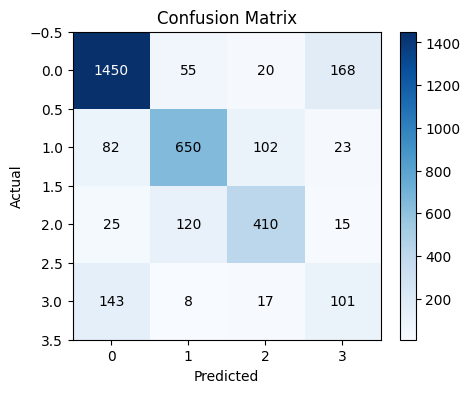

In [20]:
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plot the Confusion Matrix
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()

# Add numbers in the boxes
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                 color='black' if cm[i, j] < cm.max()/2 else 'white')

plt.show()

In [21]:
# Merge High (2) and Very High (3) into a single High-risk class (2)
df["Risk_Level_Merged"] = df["Risk_Level"].replace({3: 2})

In [22]:
feature_cols = [c for c in df.columns if c not in ["Data_Value", "Risk_Level", "Age", "Risk_Level_Merged"]]

X = df[feature_cols]
y = df["Risk_Level_Merged"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
xgb_clf = XGBClassifier(
    n_estimators=600,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

xgb_clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.85, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=-1,
              num_parallel_tree=None, ...)

In [25]:
# PREDICTIONS
y_train_pred = xgb_clf.predict(X_train)
y_test_pred = xgb_clf.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
balanced_acc = balanced_accuracy_score(y_test, y_test_pred)

print(f"\nTuned Model Results")
print(f"Training Accuracy:       {train_acc:.4f}")
print(f"Test Accuracy:           {test_acc:.4f}")
print(f"Balanced Test Accuracy:  {balanced_acc:.4f}\n")

print("Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred))


Tuned Model Results
Training Accuracy:       0.8785
Test Accuracy:           0.8287
Balanced Test Accuracy:  0.7822

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.85      0.97      0.91      1129
           1       0.77      0.78      0.77       571
           2       0.85      0.60      0.70       559

    accuracy                           0.83      2259
   macro avg       0.82      0.78      0.79      2259
weighted avg       0.83      0.83      0.82      2259



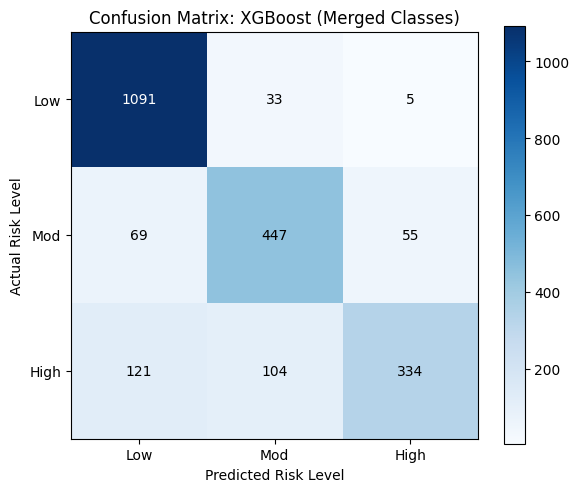

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Use y_test_pred (test predictions) instead of y_train_pred
cm = confusion_matrix(y_test, y_test_pred)

# Plotting
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix: XGBoost (Merged Classes)')
plt.xlabel('Predicted Risk Level')
plt.ylabel('Actual Risk Level')
plt.colorbar()

# Define class labels for the axes (0=Low, 1=Mod, 2=High)
tick_marks = [0, 1, 2]
plt.xticks(tick_marks, ['Low', 'Mod', 'High'])
plt.yticks(tick_marks, ['Low', 'Mod', 'High'])

# 3. Add numbers in the boxes
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, format(cm[i, j], 'd'),
            ha='center',
            va='center',
            color='black' if cm[i, j] < cm.max()/2 else 'white'
        )

plt.tight_layout()
plt.show()

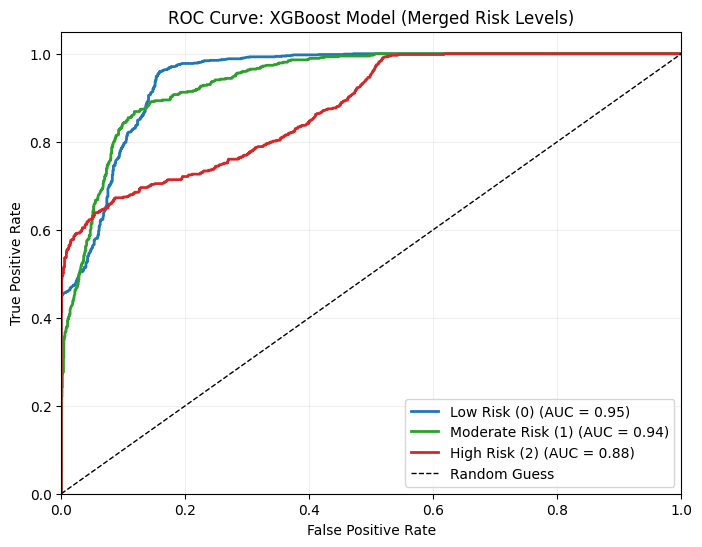

In [27]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

#  Binarize the labels for the 3 merged classes
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3

# Get predicted probabilities from XGBoost
y_score = xgb_clf.predict_proba(X_test)

# Plotting
plt.figure(figsize=(8, 6))
colors = ['#1f77b4', '#2ca02c', '#d62728'] # Blue, Green, Red
labels = ['Low Risk (0)', 'Moderate Risk (1)', 'High Risk (2)']

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'{labels[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: XGBoost Model (Merged Risk Levels)')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

## KFold Cross Validation

In [18]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb_clf, X, y, cv=50, scoring='accuracy')
print(f"CV Accuracy: {scores.mean():.4f}")

CV Accuracy: 0.7108
